In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    matthews_corrcoef,
)

qwen_output_path = Path("data/blame_results.json")
gold_test_path = Path("data/validation_set.jsonl")
out_dir = Path("out")
out_dir.mkdir(exist_ok=True)

## 1. Load and align Qwen output with gold labels

In [2]:
def load_qwen_output(path) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        records = json.load(f)

    df = pd.DataFrame(records)

    #validate columns
    for col in ["idx", "sentence", "anklage"]:
        assert col in df.columns, f"Missing expected column: '{col}'"

    # Sort by idx to ensure alignment with gold set
    df = df.sort_values("idx").reset_index(drop=True)

    print(f"Loaded {len(df)} Qwen predictions.")
    print(f"true (blame): {(df['anklage'] == True).sum()}")
    print(f"false (no blame): {(df['anklage'] == False).sum()}")
    print(f"null (abstain): {df['anklage'].isna().sum()}")
    return df


def load_gold_test(path: Path) -> pd.DataFrame:
    """Load the human-annotated gold test set from JSONL."""
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    df = pd.DataFrame(records)

    # Normalise label to int
    if df["label"].dtype == object:
        label_map = {
            "blame": 1, "Blame": 1, "BLAME": 1, "yes": 1, "1": 1,
            "no blame": 0, "No blame": 0, "NO_BLAME": 0, "no": 0, "0": 0,
        }
        df["label"] = df["label"].map(label_map)

    df["label"] = df["label"].astype(int)
    print(f"Loaded {len(df)} gold sentences.")
    return df


df_qwen = load_qwen_output(qwen_output_path)
df_gold = load_gold_test(gold_test_path)

Loaded 424 Qwen predictions.
true (blame): 42
false (no blame): 314
null (abstain): 68
Loaded 424 gold sentences.


In [3]:
def align_on_sentence(df_qwen, df_gold) -> pd.DataFrame:
    #trying text-based join first
    gold_text_col = "text" if "text" in df_gold.columns else df_gold.columns[0]

    merged = pd.merge(
        df_gold[[gold_text_col, "label"]].rename(columns={gold_text_col: "sentence"}),
        df_qwen[["sentence", "anklage"]],
        on="sentence",
        how="inner",
    )
    if len(merged) == 0:
        print("Text join found 0 matches — falling back to positional alignment.")
        n = min(len(df_gold), len(df_qwen))
        merged = pd.DataFrame({
            "sentence": df_gold[gold_text_col].iloc[:n].values,
            "label": df_gold["label"].iloc[:n].values,
            "anklage": df_qwen["anklage"].iloc[:n].values,
        })

    n_unmatched = len(df_gold) - len(merged)
    print(f"Matched: {len(merged)} sentences  |  Unmatched: {n_unmatched}")
    if n_unmatched > 0:
        print("Unmatched sentences will be excluded from evaluation.")

    return merged


df_aligned = align_on_sentence(df_qwen, df_gold)

Matched: 426 sentences  |  Unmatched: -2


## 2. Null-handling strategies

The model output contains three values: `true`, `false`, and `null`.
Three strategies for handling `null` are evaluated as a sensitivity analysis.

In [4]:
null_strategies = {
    "Abstain":-1, #excluded from metrics
    "Default no blame": 0, #treat null as no blame
    "Default blame": 1, # treat null as blame
}

def apply_null_strategy(anklage_series, null_value) -> list[int]:
    """
    Convert the raw anklage column to integer predictions.
    """
    preds = []
    for val in anklage_series:
        if val is True or val == 1:
            preds.append(1)
        elif val is False or val == 0:
            preds.append(0)
        else:
            preds.append(null_value)
    return preds

def compute_metrics(preds, labels, name) -> dict:
    """
    Compute standard classification metrics, excluding -1.
    """
    pairs = [(p, l) for p, l in zip(preds, labels) if p != -1]
    n_abstained = sum(1 for p in preds if p == -1)
    p_clean = [p for p, _ in pairs]
    print(f'len p clean {len(p_clean)}')
    l_clean = [l for _, l in pairs]

    return {
        "model": name,
        "n_evaluated": len(pairs),
        "n_abstained": n_abstained,
        "precision": round(precision_score(l_clean, p_clean, average="macro", zero_division=0), 4),
        "recall": round(recall_score(l_clean, p_clean, average="macro", zero_division=0), 4),
        "f1": round(f1_score(l_clean, p_clean, average="macro", zero_division=0), 4),
        "f1_blame": round(f1_score(l_clean, p_clean, pos_label=1, average="binary", zero_division=0), 4),
        "f1_no_blame": round(f1_score(l_clean, p_clean, pos_label=0, average="binary", zero_division=0), 4),
        "accuracy": round(accuracy_score(l_clean, p_clean), 4),
        "mcc": round(matthews_corrcoef(l_clean, p_clean), 4),
        "_preds": p_clean,
        "_labels": l_clean,
    }

gold_labels  = df_aligned["label"].tolist()
qwen_results = []

for strategy_name, null_value in null_strategies.items():
    preds   = apply_null_strategy(df_aligned["anklage"], null_value)
    print(len(preds))
    metrics = compute_metrics(preds, gold_labels, name=f"Qwen ({strategy_name})")
    print(metrics)
    qwen_results.append(metrics)

    # Also cache to out so the main notebook can load them
    cache_path = out_dir / f"qwen_{strategy_name}.json"
    with open(cache_path, "w") as f:
        json.dump(preds, f)
print(len(qwen_results[0]["_preds"]))
df_qwen_results = pd.DataFrame(qwen_results)
display_cols = ["model", "precision", "recall", "f1", "f1_blame", "accuracy", "mcc", "n_evaluated", "n_abstained"]
print(df_qwen_results[display_cols].to_string(index=False))

426
len p clean 358
{'model': 'Qwen (Abstain)', 'n_evaluated': 358, 'n_abstained': 68, 'precision': 0.9098, 'recall': 0.7121, 'f1': 0.7483, 'f1_blame': 0.5957, 'f1_no_blame': 0.9009, 'accuracy': 0.8408, 'mcc': 0.5897, '_preds': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## 3. Classification reports per strategy

In [5]:
for row in qwen_results:
    if "_preds" not in row:
        continue
    print(f"\n{'='*55}")
    print(f"{row['model']}")
    print(f"Abstained: {row['n_abstained']} / {len(gold_labels)} sentences")
    print('='*55)
    print(classification_report(
        row["_labels"], row["_preds"],
        target_names=["no blame", "blame"],
    ))


Qwen (Abstain)
Abstained: 68 / 426 sentences
              precision    recall  f1-score   support

    no blame       0.82      1.00      0.90       259
       blame       1.00      0.42      0.60        99

    accuracy                           0.84       358
   macro avg       0.91      0.71      0.75       358
weighted avg       0.87      0.84      0.82       358


Qwen (Default no blame)
Abstained: 0 / 426 sentences
              precision    recall  f1-score   support

    no blame       0.72      1.00      0.84       278
       blame       1.00      0.28      0.44       148

    accuracy                           0.75       426
   macro avg       0.86      0.64      0.64       426
weighted avg       0.82      0.75      0.70       426


Qwen (Default blame)
Abstained: 0 / 426 sentences
              precision    recall  f1-score   support

    no blame       0.82      0.93      0.87       278
       blame       0.83      0.61      0.71       148

    accuracy                   

## 4. Null-strategy sensitivity plot

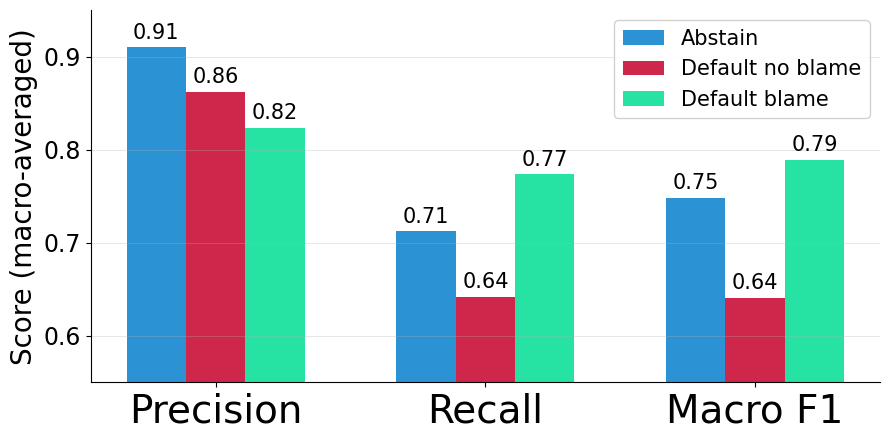

Saved: results/qwen_null_sensitivity.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

#BlameBERT reference
blamebert_f1 = 0.80
metrics_to_plot = ["precision", "recall", "f1",]
metric_labels = ["Precision", "Recall", "Macro F1"]
strategies = [r["model"].replace("Qwen (", "").rstrip(")") for r in qwen_results]
colours = ["#0680cd", "#c7002bd6", "#00de94"]

x = np.arange(len(metrics_to_plot))
width = 0.22

fig, ax = plt.subplots(figsize=(9, 4.5))

for i, (row, colour, strategy) in enumerate(zip(qwen_results, colours, strategies)):
    values = [row.get(m, np.nan) for m in metrics_to_plot]
    offset = (i - 1) * width # centre the three bars
    bars = ax.bar(x + offset, values, width, label=strategy, color=colour, alpha=0.85)

    for bar, val in zip(bars, values):
        if not np.isnan(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.2f}",
                ha="center", va="bottom", fontsize=15,
            )

#ax.axhline(blamebert_f1, color="#2c7bb6", linewidth=1.2, linestyle="--",
#           label=f"BlameBERT macro F1 = {blamebert_f1:.2f}")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=28)
ax.tick_params(axis='y', labelsize=17)
ax.set_ylim(0.55, 0.95)
ax.set_ylabel("Score (macro-averaged)", fontsize=20)
#ax.set_title(
#    "Qwen 3.5:9B zero-shot sensitivity to null-handling strategy",
#    fontsize=12, pad=10,)
ax.legend(fontsize=15, framealpha=0.9, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3, linewidth=0.7)

plt.tight_layout()
plt.savefig(out_dir / "qwen_null_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/qwen_null_sensitivity.png")

In [7]:
save_cols = ["model", "precision", "recall", "f1", "f1_blame", "f1_no_blame",
             "accuracy", "mcc", "n_evaluated", "n_abstained"]

df_save = df_qwen_results[[c for c in save_cols if c in df_qwen_results.columns]]
df_save.to_csv(out_dir / "qwen_results_summary.csv", index=False)
print("Saved: results/qwen_results_summary.csv")
print()
print(df_save.to_string(index=False))

Saved: results/qwen_results_summary.csv

                  model  precision  recall     f1  f1_blame  f1_no_blame  accuracy    mcc  n_evaluated  n_abstained
         Qwen (Abstain)     0.9098  0.7121 0.7483    0.5957       0.9009    0.8408 0.5897          358           68
Qwen (Default no blame)     0.8620  0.6419 0.6410    0.4421       0.8399    0.7512 0.4533          426            0
   Qwen (Default blame)     0.8234  0.7733 0.7887    0.7054       0.8721    0.8216 0.5946          426            0
